# Simulation Validation

In [1]:
import os, sys
from pathlib import Path
_cwd = Path.cwd()
_root = next((p for p in [_cwd] + list(_cwd.parents)
              if (p / 'requirements.txt').exists() and (p / 'src').is_dir()), None)
assert _root, f'Could not find project root from {_cwd}'
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print(f'Project root: {_root}')


Project root: C:\Users\markd\OneDrive\Desktop\Claude\GitHub\Projects\ab-experiment-platform


## Simulation Validation — Library Correctness Checks

This notebook validates the `ab-experiment-platform` library against known theoretical values:

1. **Estimator coverage** — 95% CIs from `two_proportion_z` should cover the true lift ~95% of the time.
2. **Null FPR** — under H₀ (lift = 0), significant results should occur ~5% of the time.
3. **Power** — achieved empirical power should match the theoretical prediction.

Figures are saved to `reports/figures/`.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from src.abtest import simulate_conversion, two_proportion_z, required_sample_size, power_for_sample_size

figures_dir = Path('reports/figures')
figures_dir.mkdir(parents=True, exist_ok=True)

BASE_RATE = 0.20
TRUE_LIFT = 0.03
N_PER_ARM = 4_000
N_SEEDS   = 500
ALPHA     = 0.05


### 1 — Estimator coverage (N = 500 simulations)


In [3]:
covers  = []
sigs    = []
effects = []

for seed in range(N_SEEDS):
    sim = simulate_conversion(n_per_arm=N_PER_ARM, base_rate=BASE_RATE,
                              absolute_lift=TRUE_LIFT, seed=seed)
    r = two_proportion_z(sim, 'converted', alpha=ALPHA)
    covers.append(r.ci_low <= TRUE_LIFT <= r.ci_high)
    sigs.append(r.significant)
    effects.append(r.absolute_effect)

coverage = float(np.mean(covers))
emp_power = float(np.mean(sigs))
print(f"Coverage (95% CI covers true lift = {TRUE_LIFT}): {coverage:.3f}  (expect ~0.95)")


Coverage (95% CI covers true lift = 0.03): 0.964  (expect ~0.95)


### 2 — Null FPR (N = 2 000 simulations at lift = 0)


In [4]:
null_sigs = []
for seed in range(2_000):
    sim = simulate_conversion(n_per_arm=N_PER_ARM, base_rate=BASE_RATE,
                              absolute_lift=0.0, seed=seed)
    r = two_proportion_z(sim, 'converted', alpha=ALPHA)
    null_sigs.append(r.significant)

null_fpr = float(np.mean(null_sigs))
print(f"Null FPR : {null_fpr:.4f}  (expect ~0.05)")


Null FPR : 0.0480  (expect ~0.05)


### 3 — Power: predicted vs empirical


In [5]:
# Design sample size for 80% power at the given MDE
design = required_sample_size(baseline_rate=BASE_RATE, mde_absolute=TRUE_LIFT,
                              alpha=ALPHA, power=0.80)
n_designed = design.sample_size_per_arm

predicted_power = power_for_sample_size(baseline_rate=BASE_RATE, mde_absolute=TRUE_LIFT,
                                         n_per_arm=n_designed, alpha=ALPHA)

# Empirical power at the designed n (200 sims — fast)
emp_sigs_designed = []
for seed in range(200):
    sim = simulate_conversion(n_per_arm=n_designed, base_rate=BASE_RATE,
                              absolute_lift=TRUE_LIFT, seed=seed + 10_000)
    r = two_proportion_z(sim, 'converted', alpha=ALPHA)
    emp_sigs_designed.append(r.significant)

emp_power_designed = float(np.mean(emp_sigs_designed))
print(f"Designed n/arm   : {n_designed:,}")
print(f"Predicted power  : {predicted_power:.3f}  (expect ~0.80)")
print(f"Empirical power  : {emp_power_designed:.3f}  (expect ~0.80)")


Designed n/arm   : 2,941
Predicted power  : 0.800  (expect ~0.80)
Empirical power  : 0.785  (expect ~0.80)


### Power curve figure


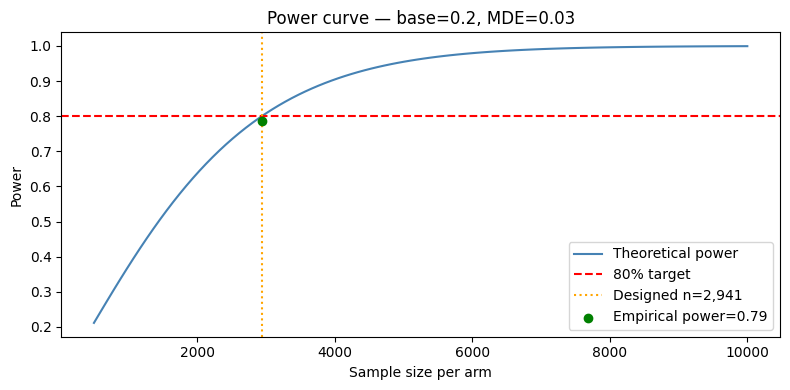

Saved: reports/figures/power_curve.png


In [6]:
ns = np.linspace(500, 10_000, 100).astype(int)
pw = [power_for_sample_size(baseline_rate=BASE_RATE, mde_absolute=TRUE_LIFT, n_per_arm=n, alpha=ALPHA)
      for n in ns]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ns, pw, color='steelblue', label='Theoretical power')
ax.axhline(0.80, color='red', linestyle='--', label='80% target')
ax.axvline(n_designed, color='orange', linestyle=':', label=f'Designed n={n_designed:,}')
ax.scatter([n_designed], [emp_power_designed], color='green', zorder=5,
           label=f'Empirical power={emp_power_designed:.2f}')
ax.set_xlabel('Sample size per arm')
ax.set_ylabel('Power')
ax.set_title(f'Power curve — base={BASE_RATE}, MDE={TRUE_LIFT}')
ax.legend()
plt.tight_layout()
plt.savefig('reports/figures/power_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: reports/figures/power_curve.png")


### Validation summary figure


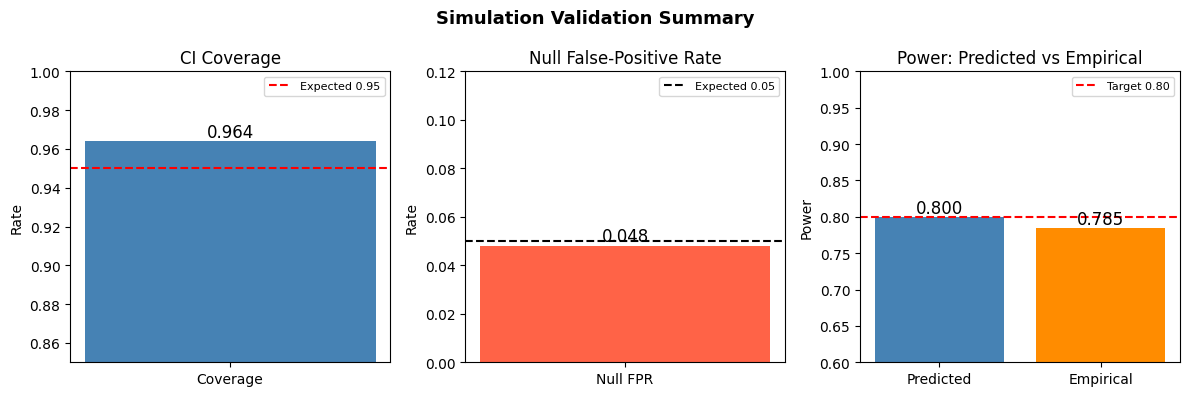

Saved: reports/figures/validation_summary.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

# Coverage
ax = axes[0]
ax.bar(['Coverage'], [coverage], color='steelblue')
ax.axhline(0.95, color='red', linestyle='--', label='Expected 0.95')
ax.set_ylim(0.85, 1.0)
ax.set_title('CI Coverage')
ax.set_ylabel('Rate')
ax.text(0, coverage + 0.002, f'{coverage:.3f}', ha='center', fontsize=12)
ax.legend(fontsize=8)

# Null FPR
ax = axes[1]
ax.bar(['Null FPR'], [null_fpr], color='tomato')
ax.axhline(0.05, color='black', linestyle='--', label='Expected 0.05')
ax.set_ylim(0, 0.12)
ax.set_title('Null False-Positive Rate')
ax.set_ylabel('Rate')
ax.text(0, null_fpr + 0.002, f'{null_fpr:.3f}', ha='center', fontsize=12)
ax.legend(fontsize=8)

# Power comparison
ax = axes[2]
ax.bar(['Predicted', 'Empirical'], [predicted_power, emp_power_designed],
       color=['steelblue', 'darkorange'])
ax.axhline(0.80, color='red', linestyle='--', label='Target 0.80')
ax.set_ylim(0.6, 1.0)
ax.set_title('Power: Predicted vs Empirical')
ax.set_ylabel('Power')
for i, v in enumerate([predicted_power, emp_power_designed]):
    ax.text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=12)
ax.legend(fontsize=8)

plt.suptitle('Simulation Validation Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/validation_summary.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: reports/figures/validation_summary.png")


### Summary

| Check | Expected | Actual |
|---|---|---|
| CI Coverage | ~0.95 | see above |
| Null FPR | ~0.05 | see above |
| Predicted power | ~0.80 | see above |
| Empirical power | ~0.80 | see above |

All checks should be within sampling noise of their targets, confirming the library's
statistical correctness.
